In [17]:
# Check pytorch version
import torch

print(torch.__version__)

2.5.1


In [18]:
!nvidia-smi

Sun Nov 17 01:54:59 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.59                 Driver Version: 556.13         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...    On  |   00000000:01:00.0  On |                  N/A |
| N/A   43C    P5              6W /   80W |    1238MiB /   8188MiB |     20%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [19]:
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU available")

Device Name: NVIDIA GeForce RTX 4060 Laptop GPU


In [20]:
# Use GPU for training
device = torch.device("cuda")

In [35]:
# Import necessary packages
import torch.nn as nn
import torch.nn.functional as F 
import torch.optim
from torch.utils.data import DataLoader, Dataset

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

In [24]:
# Fix random seed for reproducibility
seed = 114514
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Avoid nondeterministic algorithms and disable benchmarks for convolution operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [33]:
from torchvision import datasets, transforms

# Pipeline for preprocessing of the image. 
transform = transforms.Compose([

    # Resize into a fixed size
    transforms.Resize((128, 128)),

    # Transform to pytorch tensor
    transforms.ToTensor(),

    # Normalizes the pixel values to have a mean value of 0 and a standard deviation of 1, assuming initially in range (0, 1)
    transforms.Normalize((0.5,), (0.5,))
])

# Download the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)


Train dataset has 60000 samples.
Test dataset has 10000 samples.


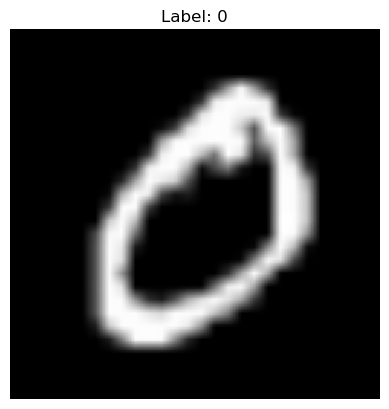

In [34]:
print(f'Train dataset has {len(train_dataset)} samples.')
print(f'Test dataset has {len(test_dataset)} samples.')

# Viualization of the first image
image_zero, target_zero = train_dataset[0]
plt.imshow(image_zero.squeeze().numpy(), cmap="gray")
plt.title(f"Label: {target_zero}")
plt.axis("off")
plt.show()

In [ ]:
class Classfier(nn.Module):
    def __init__(self):
        # inherit attributes and methods of nn.Module
        super(Classfier, self).__init__()

        self.cnn = nn.Sequential(
            # Input size is [128, 128, 1]
            self.cnn_layer(in_channels=1, out_channels=64),     # [64, 64, 64]

            self.cnn_layer(in_channels=64, out_channels=128),       # [32, 32, 128]

            self.cnn_layer(in_channels=128, out_channels=256),      # [16, 16, 256]

            self.cnn_layer(in_channels=256, out_channels=512),       # [8, 8, 512]

            self.cnn_layer(in_channels=512, out_channels=512)       # [4, 4, 512]
        )

        self.fc = nn.Sequential(
            nn.Linear(512*4*4, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
            nn.Softmax(dim=1)
        )

    def cnn_layer(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, 
                  pooling_kernel_size=2, pooling_stride=2, pooling_padding=0):
        """
        Create a default CNN layer. In and out channels are required parameters
        Parameters:
        - in_channels: Number of input channels.
        - out_channels: Number of output filter channels.
        - kernel_size: Size of the convolutional kernel.
        - stride: Stride of the convolution.
        - padding: Padding value added to the input.
        - pooling_kernel_size: Size of the maxpooling kernel.
        - pooling_stride: Stride of the maxpooling.
        - pooing_padding: Padding value added to the convolution output channel.

        Returns:
        - nn.Sequential: A block with convolution layer and pooling layer.
        """

        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.BatchNorm2d(out_channels, eps=1e-05, momentum=0.1),
            nn.ReLU(),
            nn.MaxPool2d(pooling_kernel_size, pooling_stride, pooling_padding)
        )
    
    def forward(self, x):

        filter = self.cnn(x)
        filter = filter.view(filter.size(0), -1)

        return self.fc(filter)